## test various settings pcr globwat

notebook that runs PCRGLOBWB for 2 years with 3 different setting:

- default setting
- no agriculture and articial lakes etc. (non human influence)
- routingwave option

--------
Also template to work on combined pcrglobwb runs


### ToDO
- split model run and analysis
- automate in .py?

In [17]:
# This cell is only used to suppress some distracting output messages
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
from datetime import datetime
from pathlib import Path

import ewatercycle.forcing
import ewatercycle.models
import ewatercycle.parameter_sets
import matplotlib.pyplot as plt
import pandas as pd
from rich import print
from tqdm.notebook import tqdm

In [3]:
Chatly_station_latitude = 42.34332908492399 - 0.5  # Amu Darya near Chatly
Chatly_station_longitude = (
    59.627516175820965 + 0.9
)  # Through trial and error, to get modelled discharge closer to observed

Kerki_station_latitude = 37.8396310038444  # Amu Darya near Kerki
Kerki_station_longitude = 65.23703868931334

Tyumen_station_latitude = 44.05 - 0.1  # Syr Darya near Tyumen, through trial and error
Tyumen_station_longitude = 67.05

Kazalinsk_station_latitude = (45.739988222442456,)  # Syr Darya near Kazalinsk
Kazalinsk_station_longitude = 62.115993992559744

In [4]:
# set start and end date of the experiment, overwrites .ini settings
experiment_start_date = "1970-01-01T00:00:00Z"
# experiment_end_date = "1992-12-31T00:00:00Z" #was 1995-12-31T00:00:00Z, shorter for testing
# experiment_end_date = "1990-02-28T00:00:00Z" #2 months, for testing
experiment_end_date = "1971-12-31T00:00:00Z"  # 2 months, for testing

In [5]:
pcr_glob_directory = Path("/data/shared/parameter-sets/pcrglobwb_global")  # GlobalOption uit .ini

prepared_PCRGlob_forcing = (
    Path(
        "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/forcing_7071"
    )
    / "AralSeaBasin"
    / "pcrglobwb"
    / "work/diagnostic/script"
)  ##MeteoOptions uit .ini

prepared_PCRGlob_forcing_CMIP = (
    Path(
        "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Comparison/forcing_CMIP_7071"
    )
    / "AralSeaBasin"
    / "CMIP"
    / "future"
    / "PCRGlobWB"
    / "work/diagnostic/script"
)  ##MeteoOptions uit .ini

In [6]:
parameter_set_agri = ewatercycle.parameter_sets.ParameterSet(
    name="custom_parameter_set",
    directory=pcr_glob_directory,
    config=Path.cwd() / "Reference_05min_agri.ini",
    target_model="pcrglobwb",
    supported_model_versions={"setters"},
)


parameter_set_no_agri = ewatercycle.parameter_sets.ParameterSet(
    name="custom_parameter_set",
    directory=pcr_glob_directory,
    config=Path.cwd() / "Reference_05min_no_agri.ini",
    target_model="pcrglobwb",
    supported_model_versions={"setters"},
)


parameter_set_RoutingWave = ewatercycle.parameter_sets.ParameterSet(
    name="custom_parameter_set",
    directory=pcr_glob_directory,
    config=Path.cwd() / "Reference_05min_RoutingWave.ini",
    target_model="pcrglobwb",
    supported_model_versions={"setters"},
)

In [7]:
forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
    directory=prepared_PCRGlob_forcing,
)


print(forcing)

PCRGlobWBForcing(
    start_time='1970-01-01T00:00:00Z',
    end_time='1971-12-31T00:00:00Z',
    directory=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in
_progress/Test_Aral/forcing_7071/AralSeaBasin/pcrglobwb/work/diagnostic/script'),
    shape=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_pro
gress/Test_Aral/forcing_7071/AralSeaBasin/pcrglobwb/work/diagnostic/script/AralSeaBasin.shp'),
    filenames={},
    precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1970-1971_AralSeaBasin.nc',
    temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_1970-1971_AralSeaBasin.nc'
)

In [8]:
model_agri = ewatercycle.models.PCRGlobWB(parameter_set=parameter_set_agri, forcing=forcing)

model_no_agri = ewatercycle.models.PCRGlobWB(parameter_set=parameter_set_no_agri, forcing=forcing)


model_routingwave = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_RoutingWave, forcing=forcing
)

In [9]:
model_agri_config, model_agri_dir = model_agri.setup(
    start_time=experiment_start_date, end_time=experiment_end_date, max_spinups_in_years=0
)


model_no_agri_config, model_no_agri_dir = model_no_agri.setup(
    start_time=experiment_start_date, end_time=experiment_end_date, max_spinups_in_years=0
)


model_routingwave_config, model_routingwave_dir = model_routingwave.setup(
    start_time=experiment_start_date, end_time=experiment_end_date, max_spinups_in_years=0
)

In [10]:
print(model_agri.parameters)

model_agri_para = model_agri.parameters

# Convert ISO 8601 strings to datetime objects
start_time = datetime.strptime(experiment_start_date, "%Y-%m-%dT%H:%M:%SZ")
end_time = datetime.strptime(experiment_end_date, "%Y-%m-%dT%H:%M:%SZ")

# Calculate the number of days for the progression bar
delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")

dict_items([('start_time', '1970-01-01T00:00:00Z'), ('end_time', '1971-12-31T00:00:00Z'), ('routing_method', 
'accuTravelTime'), ('max_spinups_in_years', '0')])

Number of days to model: 729

In [11]:
model_agri.initialize(model_agri_config)
model_no_agri.initialize(model_no_agri_config)
model_routingwave.initialize(model_routingwave_config)

In [12]:
time = pd.date_range(model_agri.start_time_as_isostr, model_agri.end_time_as_isostr)

In [13]:
experiments = {
    "agri": model_agri,
    "no_agri": model_no_agri,
    "routing_wave": model_routingwave,
}

In [14]:
stations = ["Chatly", "Kerki", "Tyumen", "Kazalinsk"]

stations_ts = {
    name: pd.DataFrame(
        index=pd.Index(time, name="time"),
        columns=stations,
        dtype=float,
    )
    for name in experiments
}

In [15]:
stations_meta = {
    "Chatly": (Chatly_station_latitude, Chatly_station_longitude),
    "Kerki": (Kerki_station_latitude, Kerki_station_longitude),
    "Tyumen": (Tyumen_station_latitude, Tyumen_station_longitude),
    "Kazalinsk": (Kazalinsk_station_latitude, Kazalinsk_station_longitude),
}

In [16]:
for _ in tqdm(range(number_of_days), desc="Running simulation"):
    for exp_name, model in experiments.items():
        model.update()
        time = model.time_as_isostr

        for station, (lat, lon) in stations_meta.items():
            q = model.get_value_at_coords(
                "discharge",
                lat=[lat],
                lon=[lon],
            )[0]

            stations_ts[exp_name].loc[time, station] = q

print("All model runs finished!")

Running simulation:   0%|          | 0/729 [00:00<?, ?it/s]

All model runs finished!

In [18]:
model_agri.finalize()
model_no_agri.finalize()
model_routingwave.finalize()

In [19]:
stations_ts["routing_wave"].to_csv("RoutingWave_7071.csv", index=True)
stations_ts["no_agri"].to_csv("Scenario_no_agri_7071.csv", index=True)
stations_ts["agri"].to_csv("Reference_7071.csv", index=True)

In [26]:
from ewatercycle.observation.grdc import get_grdc_data

ds = get_grdc_data(
    2617110,
    "1971-01-01T00:00Z",
    "1971-12-31T00:00Z",
    data_home="/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/",
)

ds

<xarray.Dataset> Size: 6kB
Dimensions:              (time: 365)
Coordinates:
  * time                 (time) datetime64[ns] 3kB 1971-01-01 ... 1971-12-31
    id                   int64 8B 2617110
Data variables:
    streamflow           (time) float64 3kB 857.0 812.0 766.0 ... 575.0 558.0
    area                 float64 8B 3.09e+05
    country              <U2 8B 'TM'
    geo_x                float64 8B 65.25
    geo_y                float64 8B 37.83
    geo_z                float64 8B 241.0
    owneroforiginaldata  <U85 340B 'Initial dataset collected in the framewor...
    river_name           <U9 36B 'AMU DARYA'
    station_name         <U5 20B 'KERKI'
    timezone             float64 8B nan
Attributes:
    title:          NA
    Conventions:    CF-1.7
    references:     grdc.bafg.de
    institution:    GRDC
    history:        Converted from 2617110_Q_Day.Cmd.txt of 2025-09-02 to net...
    missing_value:  -999.000

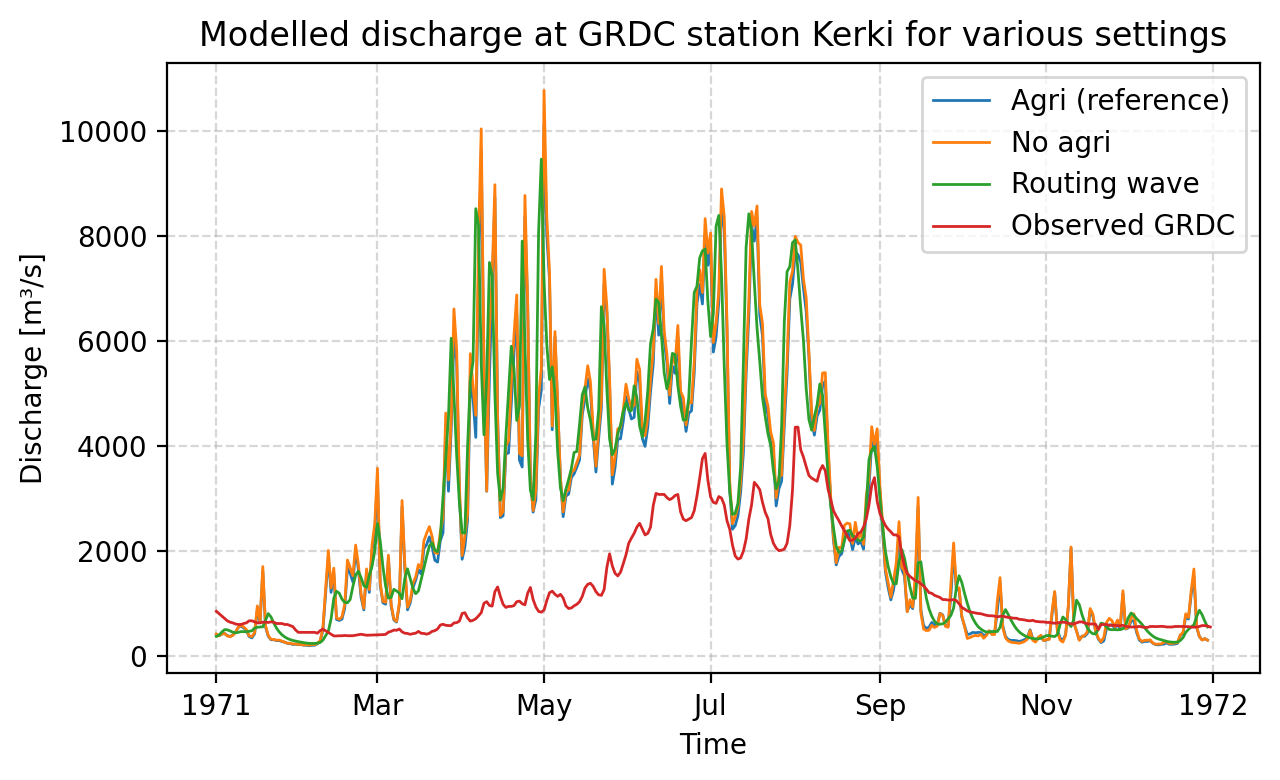

In [35]:
# Slice only 1970
start = "1971-01-01"
end = "1971-12-31"

plt.figure(figsize=(6.5, 4.0), dpi=200)

plt.plot(stations_ts["agri"]["Kerki"].loc[start:end], label="Agri (reference)", linewidth=1)
plt.plot(stations_ts["no_agri"]["Kerki"].loc[start:end], label="No agri", linewidth=1)
plt.plot(stations_ts["routing_wave"]["Kerki"].loc[start:end], label="Routing wave", linewidth=1)

ds["streamflow"].plot(label="Observed GRDC", linewidth=1)
plt.xlabel("Time")
plt.ylabel("Discharge [m³/s]")
plt.title("Modelled discharge at GRDC station Kerki for various settings")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig("../../../outputs/figures/settings_pcrglob_kerki_1971.png")
plt.show()